In [25]:
import pandas as pd
import numpy as np
import os

!pip install torch torchvision torchmetrics
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [38]:
df = pd.read_csv('02_real_data/real_dataset.tsv', sep='\t', index_col=0)
patient_codes = df.columns

/tmp/ipykernel_41723/128294331.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('02_real_data/real_dataset.tsv', sep='\t', index_col=0)


In [27]:
conditions = df.T['Conditions']
sample_data = df.T.drop(columns=['Conditions'])



#normalisation skipped for now discussion in meeting
sample_data = sample_data.reset_index(drop=True).to_numpy(dtype=np.float32)

sample_data_normalized = (sample_data - sample_data.mean(axis=0))/sample_data.std(axis=0)
sample_data_normalized = np.nan_to_num(sample_data_normalized)

/tmp/ipykernel_41723/2200523836.py:9: RuntimeWarning: invalid value encountered in divide
  sample_data_normalized = (sample_data - sample_data.mean(axis=0))/sample_data.std(axis=0)


In [28]:
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

In [29]:
# Define Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

# Define Decoder
class Decoder(nn.Module):
    def __init__(self, latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim_3),
            nn.ReLU(),
            nn.Linear(hidden_dim_3, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, input_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

# Define GOAE Model
class GOAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(GOAE, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
        self.decoder = Decoder(latent_dim, input_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
    
    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return z, x_reconstructed


In [30]:
# Orthogonality Loss
def orthogonality_loss(z):
    zt_z = torch.matmul(z.T, z)
    identity = torch.eye(zt_z.size(0), device=z.device)
    return torch.norm(zt_z - identity, p='fro')**2

In [31]:
# Training
def train_goae(model, data_loader, epochs=50, latent_dim=10, learning_rate=1e-3, lambda_ortho=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        total_loss = 0
        for x_batch in data_loader:
            x_batch = x_batch[0]
           
            # Forward pass
            z, x_reconstructed = model(x_batch)
            
            # Loss
            reconstruction_loss = criterion(x_reconstructed, x_batch)
            ortho_loss = orthogonality_loss(z)
            loss = reconstruction_loss + lambda_ortho * ortho_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(data_loader)}")


proteomics_ds = TensorDataset(proteomics_tensor)
proteomics_dl = DataLoader(proteomics_ds, batch_size=64, shuffle=True)
input_dim = proteomics_tensor.shape[1]
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
latent_dim = 10
epochs = 150

goae_model = GOAE(input_dim, latent_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3)
train_goae(goae_model, proteomics_dl, epochs=epochs)


Epoch 1, Loss: 265686.96367196244
Epoch 2, Loss: 11515.672629038492
Epoch 3, Loss: 14085.135507742563
Epoch 4, Loss: 2239.9886105855308
Epoch 5, Loss: 204.98015117645264
Epoch 6, Loss: 534.9052927494049
Epoch 7, Loss: 621.5902853806814
Epoch 8, Loss: 204.1407653093338
Epoch 9, Loss: 33.13105082511902
Epoch 10, Loss: 8.065676053365072
Epoch 11, Loss: 15.104140837987265
Epoch 12, Loss: 33.43496108055115
Epoch 13, Loss: 24.454957803090412
Epoch 14, Loss: 9.621639649073282
Epoch 15, Loss: 4.379125277201335
Epoch 16, Loss: 2.6341139872868857
Epoch 17, Loss: 2.1468685468037925
Epoch 18, Loss: 2.00543204943339
Epoch 19, Loss: 2.022351940472921
Epoch 20, Loss: 1.7759320735931396
Epoch 21, Loss: 1.8373169898986816
Epoch 22, Loss: 1.6944445768992107
Epoch 23, Loss: 1.701934814453125
Epoch 24, Loss: 1.6588048140207927
Epoch 25, Loss: 1.5967039267222087
Epoch 26, Loss: 1.4981671969095867
Epoch 27, Loss: 1.499468485514323
Epoch 28, Loss: 1.5588634411493938
Epoch 29, Loss: 1.6044504642486572
Epoch 3

In [32]:
def extract_latent_space(model, data_loader):
    model.encoder.fc.eval()
    latent_representations = []
    with torch.no_grad():
        for batch in data_loader:
            bach_latent_reepresentation = model.encoder(batch)
           
            latent_representations.append(bach_latent_reepresentation)
    return np.vstack(latent_representations)

latent_representations = extract_latent_space(goae_model, proteomics_tensor)

In [33]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

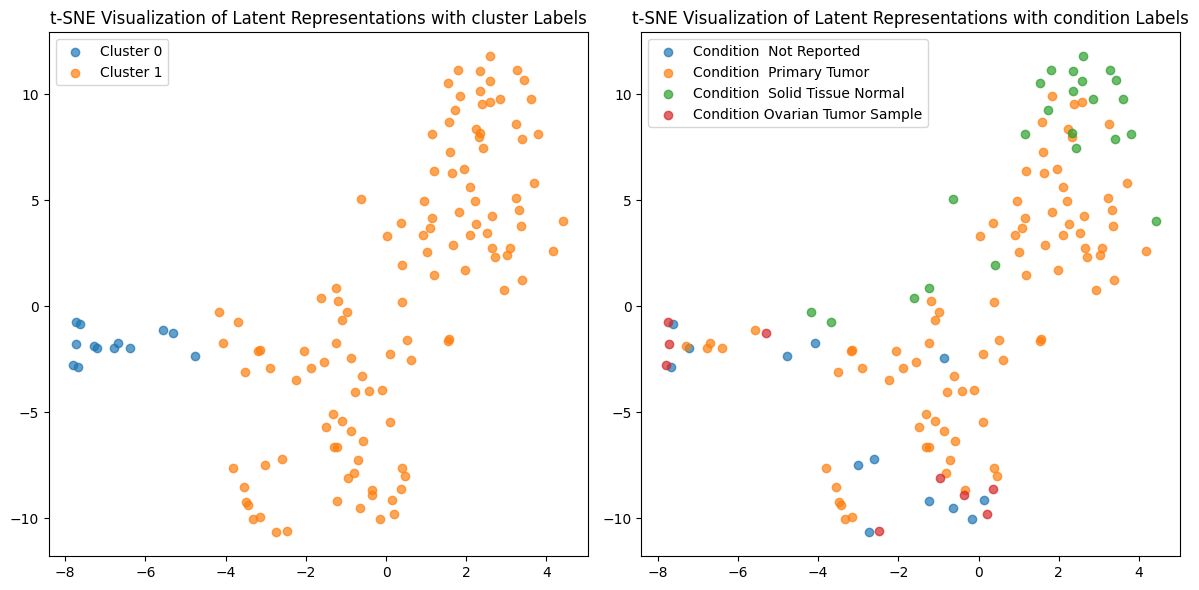

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
experiment_codes = np.array([patient_code.split("_")[0] for patient_code in patient_codes.to_list()])
experiment_codes

array(['01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC',
       '01CPTAC', '01CPTAC', '01CPTAC', '01CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC', '02CPTAC',
       '02CPTAC', '02CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC', '03CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC',
       '04CPTAC', '04CPTAC', '04CPTAC', '04CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC', '05CPTAC',
       '05CPTAC', '05CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC', '06CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC',
       '07CPTAC', '07CPTAC', '07CPTAC', '07CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC', '08CPTAC',
       '08CPTAC', '08CPTAC', '09CPTAC', '09CPTAC', 

[ True  True  True  True  True  True  True  True  True  True False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False]
[False False False False False False False False False False  True  True
  True  True  True  True  True  True  True  True False False False False
 False False False False False False False False False False F

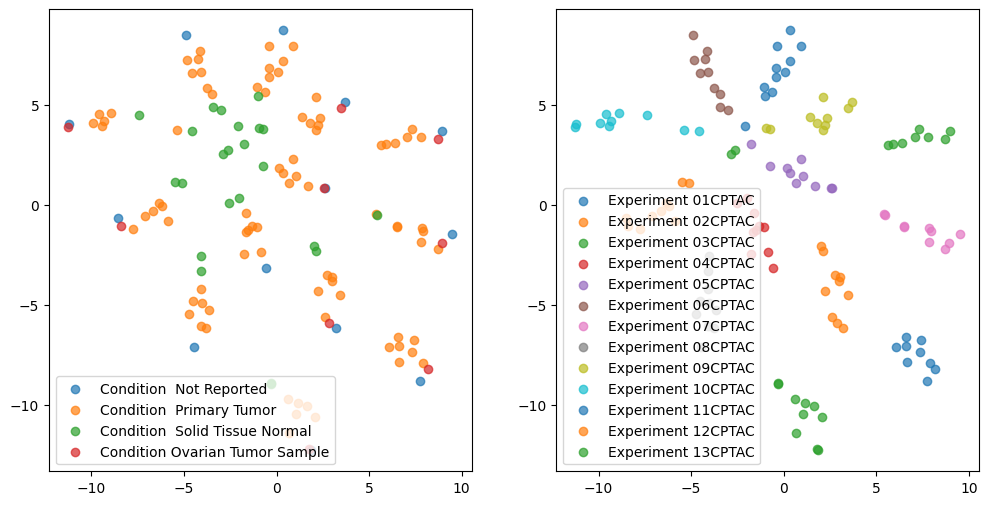

In [47]:
## baseline using TSNE

fig, axes = plt.subplots(1, 2, figsize=(12, 6))




tsne = TSNE(n_components=2, random_state=0)
df_2d = tsne.fit_transform(sample_data_normalized)
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[0].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[0].legend()

unique_experiments = np.unique(experiment_codes)

for experiment in unique_experiments:
    indices = (experiment_codes == experiment)
    axes[1].scatter(
        df_2d[indices, 0],
        df_2d[indices, 1],
        label=f'Experiment {experiment}',
        alpha=0.7
    )
axes[1].legend()

